In [1]:
import nmrglue as ng
import pandas as pd
import matplotlib.pyplot as plt

#### **Objective: Unbin H8 Data to confirm viablity**

In [2]:
# Path to the processed data (pdata/1)
path = "data/400MHz/H8/10/pdata/1"

# Read processed spectrum
dic, data = ng.bruker.read_pdata(path)   # data will be a 1D array (real part from 1r)

In [3]:
# Step 2: Create a units converter for the ppm scale
udic = ng.bruker.guess_udic(dic, data)
uc = ng.fileiobase.uc_from_udic(udic)


In [4]:
# Step 3: Generate the full ppm scale and export
ppm_scale = uc.ppm_scale()
df = pd.DataFrame({"ppm": ppm_scale, "intensity": data})
df.to_csv("H8_unbinned_spectrum.csv", index=False)

print(f"Success! Unbinned spectrum saved with {len(data)} points.")

Success! Unbinned spectrum saved with 65536 points.


In [5]:
df.head()

,ppm,intensity
0,15.128352,2731.25
1,15.128039,3514.25
2,15.127725,3872.75
3,15.127411,4773.00
4,15.127098,5282.25


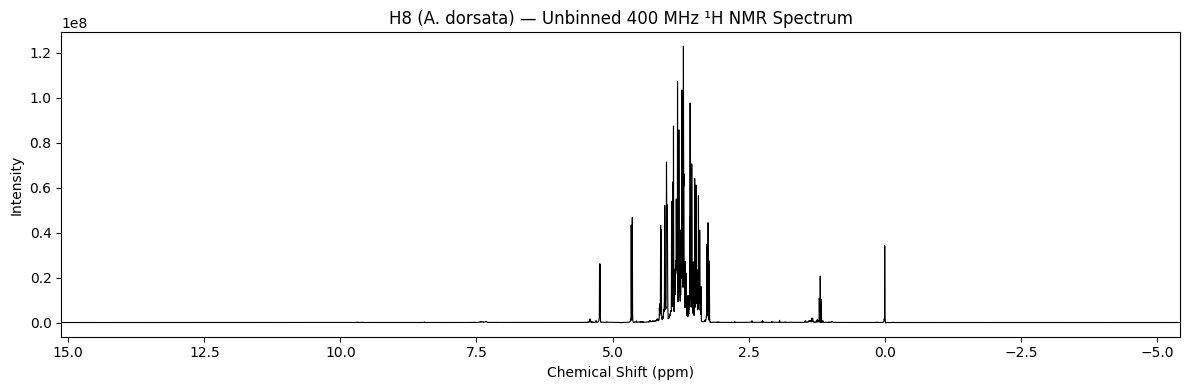

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(ppm_scale, data, linewidth=0.8, color='black')
plt.xlabel('Chemical Shift (ppm)')
plt.ylabel('Intensity')
plt.title('H8 (A. dorsata) — Unbinned 400 MHz ¹H NMR Spectrum')
plt.xlim(max(ppm_scale), min(ppm_scale))  # NMR convention: right to left
plt.tight_layout()
plt.savefig('H8_unbinned_spectrum.png', dpi=150)
plt.show()

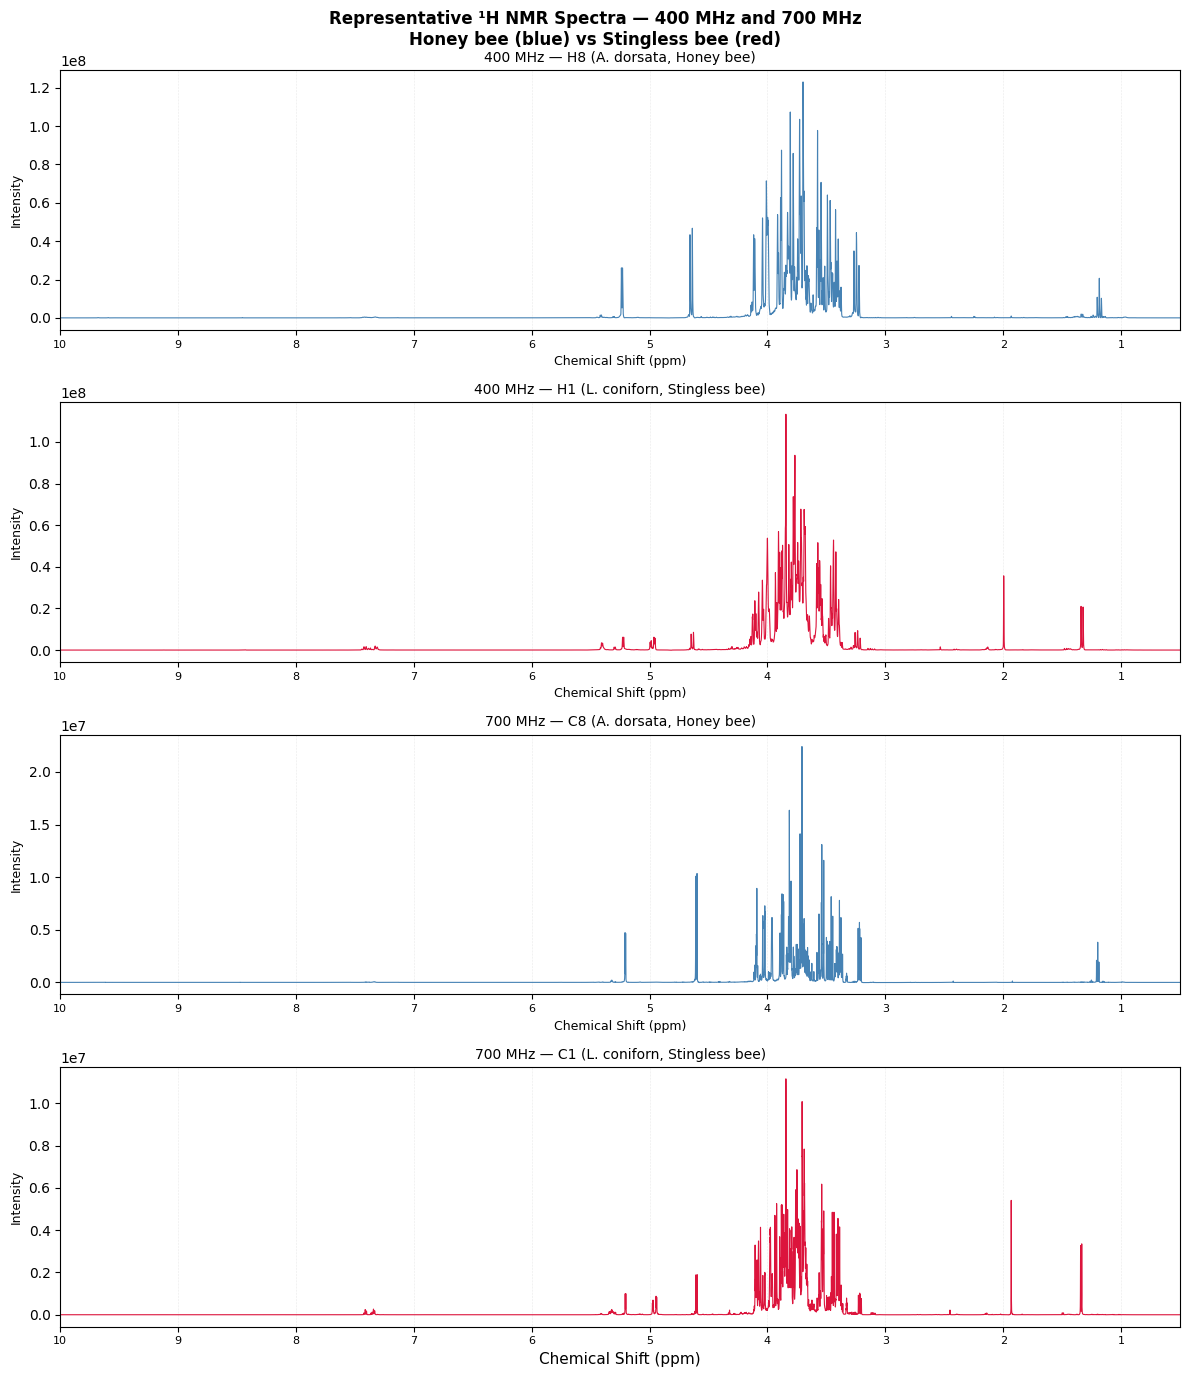

Done — saved as figure_spectra.png


In [4]:
import nmrglue as ng
import numpy as np
import matplotlib.pyplot as plt

samples = [
    ("data/400MHz/H8/10/pdata/1",  "400 MHz — H8 (A. dorsata, Honey bee)",     "steelblue"),
    ("data/400MHz/H1/10/pdata/1",  "400 MHz — H1 (L. coniforn, Stingless bee)", "crimson"),
    ("data/700MHz/C8/pdata/1",  "700 MHz — C8 (A. dorsata, Honey bee)",      "steelblue"),
    ("data/700MHz/C1/pdata/1",  "700 MHz — C1 (L. coniforn, Stingless bee)", "crimson"),
]

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

for ax, (path, label, color) in zip(axes, samples):
    dic, data = ng.bruker.read_pdata(path)
    udic = ng.bruker.guess_udic(dic, data)
    uc = ng.fileiobase.uc_from_udic(udic)
    ppm = uc.ppm_scale()
    mask = (ppm > 0.5) & (ppm < 10.0)
    ax.plot(ppm[mask], np.real(data)[mask],
            linewidth=0.8, color=color)
    ax.set_ylabel("Intensity", fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.invert_xaxis()
    ax.set_xlim(10.0, 0.5)

    # --- fix: force ppm ticks/labels to show on every panel ---
    ax.tick_params(axis='x', labelbottom=True, labelsize=8)
    ax.set_xlabel("Chemical Shift (ppm)", fontsize=9)
    ax.set_xticks(range(10, 0, -1))  # tick every 1 ppm: 10,9,8...1
    ax.grid(axis='x', linestyle=':', linewidth=0.4, alpha=0.5)

axes[-1].set_xlabel("Chemical Shift (ppm)", fontsize=11)

plt.suptitle(
    "Representative ¹H NMR Spectra — 400 MHz and 700 MHz\n"
    "Honey bee (blue) vs Stingless bee (red)",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig("figure6a_spectra.png", dpi=150, bbox_inches='tight')
plt.show()
print("Done — saved as figure_spectra.png")